# 02 EDA

This notebook performs the required exploratory data analysis for:
- `EverCigaretteUse` (behavior variable)
- `HowMuchDoYouWeighWithoutShoesInKG` (continuous variable)

It also includes an additional subgroup exploration using `WhatIsYourSex` codes.


## 1. Data

In [190]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams['figure.dpi'] = 120

ROOT = Path.cwd().resolve().parent
PROCESSED_PATH = ROOT / "data" / "processed" / "yrbs_selected_cleaned.csv"
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"

BEHAVIOR_VAR = "EverCigaretteUse"
CONT_VAR = "HowMuchDoYouWeighWithoutShoesInKG"

processed = pd.read_csv(PROCESSED_PATH)
print("Processed data shape:", processed.shape)
processed.head()

Processed data shape: (14041, 4)


,WhatIsYourSex,EverCigaretteUse,behavior_binary,HowMuchDoYouWeighWithoutShoesInKG
0,2.0,1.0,1.0,NaN
1,2.0,1.0,1.0,68.04
2,2.0,NaN,NaN,NaN
3,1.0,1.0,1.0,79.38
4,1.0,NaN,NaN,NaN


In [ ]:
#Copy
behavior = processed[[BEHAVIOR_VAR, "behavior_binary", "WhatIsYourSex"]].copy()
behavior_valid = behavior.dropna(subset=["behavior_binary"]).copy()
cont = processed[[CONT_VAR, "WhatIsYourSex"]].copy()
cont_valid = cont.dropna(subset=[CONT_VAR]).copy()

## 2. Behavior Variable EDA

### 2.1 Table of original code frequencies

,raw_code,count,proportion
0,1.0,7164,0.510
1,2.0,6437,0.458
2,Missing or invalid,440,0.031


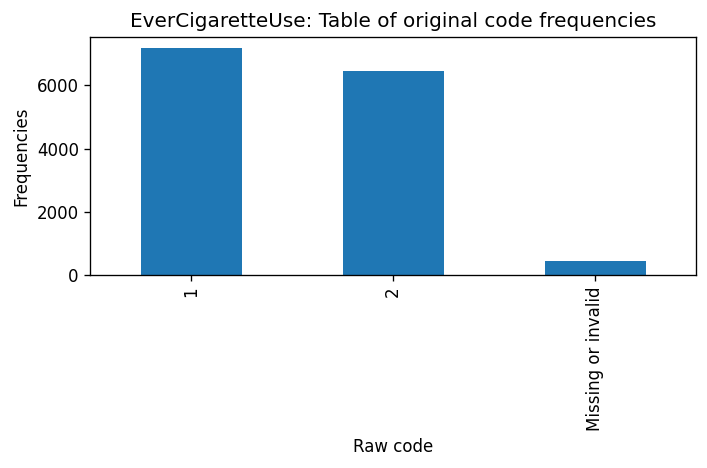

In [185]:
#----------表----------
behavior_raw_freq = (
    behavior[BEHAVIOR_VAR]
    .value_counts(dropna=False)
    .rename_axis("raw_code")
    .reset_index(name="count")
)

behavior_raw_freq["raw_code"] = behavior_raw_freq["raw_code"].astype("object")
behavior_raw_freq["raw_code"] = behavior_raw_freq["raw_code"].where(
    behavior_raw_freq["raw_code"].notna(), "Missing or invalid"
)

behavior_raw_freq["proportion"] = (
    behavior_raw_freq["count"] / behavior_raw_freq["count"].sum()
).round(3)

display(behavior_raw_freq)
#----------圖表----------
raw_plot_counts = (
    behavior[BEHAVIOR_VAR]
    .astype("object")
    .where(behavior[BEHAVIOR_VAR].notna(), "Missing or invalid")
    .value_counts(dropna=False)
    .reindex([1, 2, "Missing or invalid"], fill_value=0)
)

plt.figure(figsize=(6, 4))
raw_plot_counts.plot(kind="bar")
plt.title("EverCigaretteUse: Table of original code frequencies")
plt.xlabel("Raw code")
plt.ylabel("Frequencies")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_behavior_original_bar_chart.png", bbox_inches="tight")
plt.show()

**Observations:** The original responses are concentrated in codes 1 and 2, with only a smaller number of missing values. This suggests that the variable is already well-structured for recoding into a binary success/failure variable for the later proportion analysis.

### 2.2 Table after binary recoding

,category,count,proportion
0,Failure (0),6437,0.473274
1,Success (1),7164,0.526726


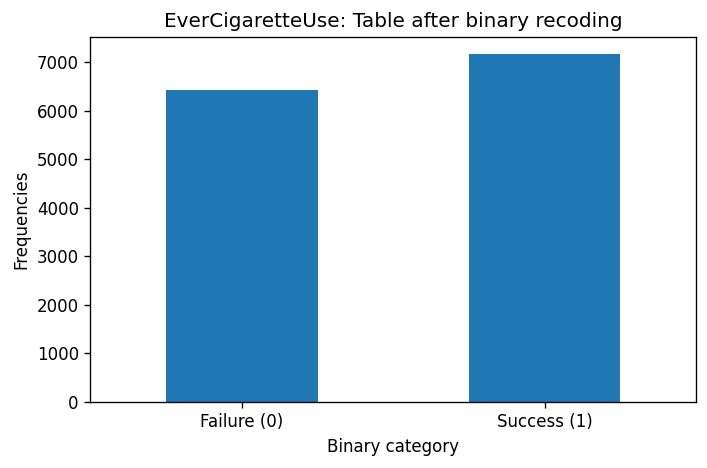

In [167]:
#----------表----------
behavior_binary_summary = pd.DataFrame({
    "category": ["Failure (0)", "Success (1)"],
    "count": [
        int((behavior_valid["behavior_binary"] == 0).sum()),
        int((behavior_valid["behavior_binary"] == 1).sum())
    ]
})
behavior_binary_summary["proportion"] = behavior_binary_summary["count"] / behavior_binary_summary["count"].sum()
behavior_binary_summary.to_csv(TAB_DIR / "02_behavior_binary_summary.csv", index=False)
display(behavior_binary_summary)
#----------圖表----------
binary_plot_counts = behavior_valid["behavior_binary"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
binary_plot_counts.plot(kind="bar")
plt.title("EverCigaretteUse: Table after binary recoding")
plt.xlabel("Binary category")
plt.ylabel("Frequencies")
plt.xticks([0, 1], ["Failure (0)", "Success (1)"], rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_behavior_binary_bar_chart.png", bbox_inches="tight")
plt.show()

**Observations:** After binary recoding, **Success (1)** accounts for **52.7%** of the valid responses, which is slightly higher than **Failure (0)** at **47.3%**. This suggests that the success category is somewhat more common in the sample and may be above the benchmark proportion of **0.50**.

### 2.3 Additional:EverCigaretteUse Success Proportion by Sex Code

,WhatIsYourSex,count,success_proportion
0,1.0,6853,0.506931
1,2.0,6736,0.546912


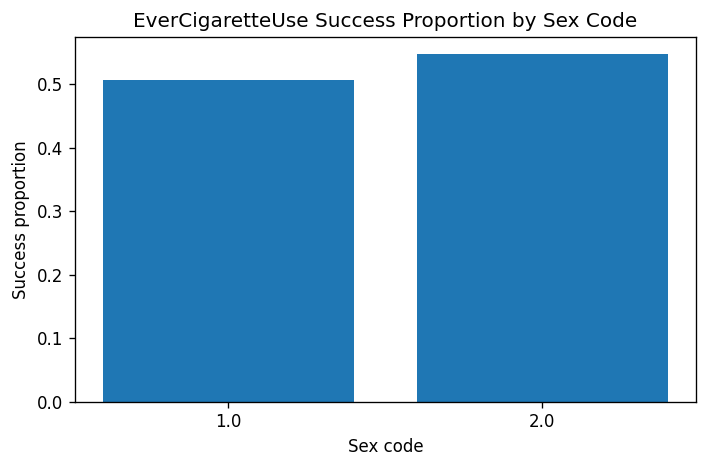

In [169]:
sex_behavior = (
    behavior_valid.groupby("WhatIsYourSex")["behavior_binary"]
    .agg(["count", "mean"])
    .reset_index()
    .rename(columns={"mean": "success_proportion"})
)
sex_behavior.to_csv(TAB_DIR / "02_behavior_by_sex_code.csv", index=False)
display(sex_behavior)

plt.figure(figsize=(6, 4))
plt.bar(sex_behavior["WhatIsYourSex"].astype(str), sex_behavior["success_proportion"])
plt.title("EverCigaretteUse Success Proportion by Sex Code")
plt.xlabel("Sex code")
plt.ylabel("Success proportion")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_behavior_by_sex_code.png", bbox_inches="tight")
plt.show()

**Observations:** The success proportion is slightly higher for **sex code 2.0** (**0.5469**) than for **sex code 1.0** (**0.5069**). This suggests a possible subgroup difference in the sample, although this result is only descriptive at the EDA stage.

## 3.Continuous Variable EDA

### 3.1 Statistic and missing or invalid value count

In [181]:
w = cont_valid[CONT_VAR]
summary_stats = pd.DataFrame({
    "statistic": ["valid size", "mean", "median", "sd", "min", "Q1", "Q3", "max"],
    "value": [
        int(w.shape[0]),
        float(w.mean()),
        float(w.median()),
        float(w.std(ddof=1)),
        float(w.min()),
        float(w.quantile(0.25)),
        float(w.quantile(0.75)),
        float(w.max())
    ]
})
summary_stats.to_csv(TAB_DIR / "02_continuous_summary_stats.csv", index=False)
display(summary_stats)

# Missing or invalid count（在 processed 中已經合併為 NaN）
cont_missing_invalid = pd.DataFrame({
    "item": ["Missing  or invalid"],
    "count": [
        int(processed[CONT_VAR].isna().sum())
    ]
})

cont_missing_invalid.to_csv(TAB_DIR / "02_continuous_missing_invalid_count.csv", index=False)
display(cont_missing_invalid)

,statistic,value
0,valid size,13062.000000
1,mean,68.550172
2,median,65.320000
3,sd,16.990868
4,min,34.470000
5,Q1,56.700000
6,Q3,77.110000
7,max,180.990000


,item,count
0,Missing or invalid,979


**Observation**: The sample mean is 68.55 kg and the median is 65.32 kg. Because the mean is above the median, the distribution appears somewhat right-skewed.

### 3.2 Histogram

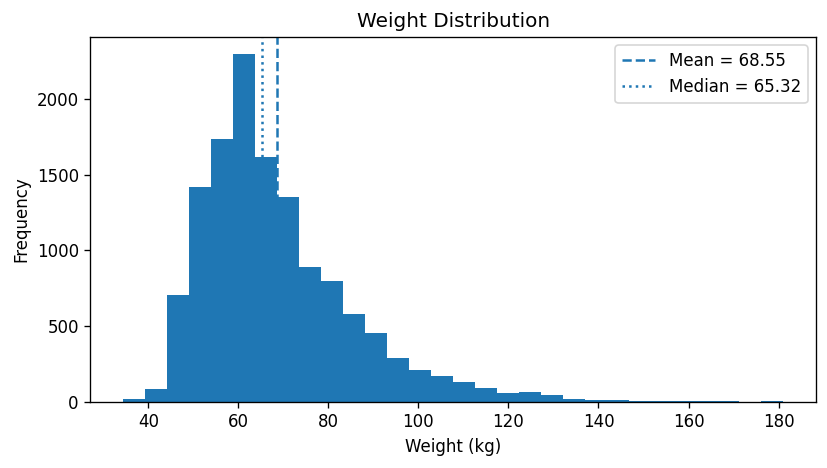

In [171]:
plt.figure(figsize=(7, 4))
plt.hist(w, bins=30)
plt.axvline(w.mean(), linestyle="--", label=f"Mean = {w.mean():.2f}")
plt.axvline(w.median(), linestyle=":", label=f"Median = {w.median():.2f}")
plt.title("Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "02_weight_histogram.png", bbox_inches="tight")
plt.show()

**Observation:** The histogram shows a single main cluster with a longer right tail. This supports the idea that unusually high weights pull the mean upward.

### 3.2 Boxplot

,metric,value
0,Q1,56.700
1,Q3,77.110
2,IQR,20.410
3,Lower fence,26.085
4,Upper fence,107.725
5,Outlier count,447.000


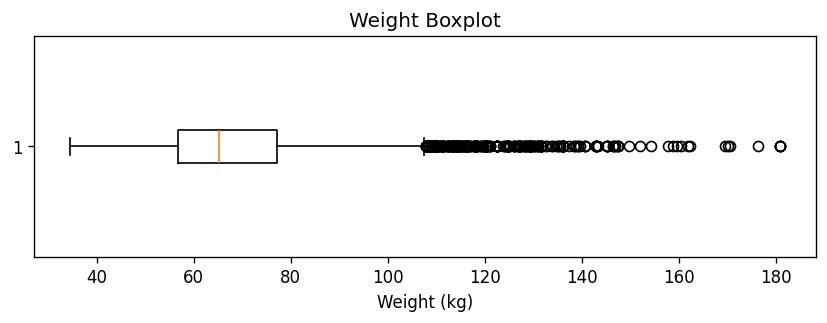

In [176]:

q1 = float(w.quantile(0.25))
q3 = float(w.quantile(0.75))
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = int(((w < lower) | (w > upper)).sum())

outlier_table = pd.DataFrame({
    "metric": ["Q1", "Q3", "IQR", "Lower fence", "Upper fence", "Outlier count"],
    "value": [q1, q3, iqr, lower, upper, outliers]
})
outlier_table.to_csv(TAB_DIR / "02_weight_outlier_check.csv", index=False)
display(outlier_table)

plt.figure(figsize=(7, 2.8))
plt.boxplot(w, vert=False)
plt.title("Weight Boxplot")
plt.xlabel("Weight (kg)")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_weight_boxplot.png", bbox_inches="tight")
plt.show()

**Observation:** The IQR rule flags 447 possible outliers. So the weight variable is not perfectly symmetric, but the sample size is very large, which helps make one-sample t procedures reasonably stable.

### 3.3 Additional:Weight by Sex Code

,WhatIsYourSex,count,mean,median,std
0,1.0,6490,62.417296,58.97,14.163778
1,2.0,6572,74.606528,70.76,17.374632


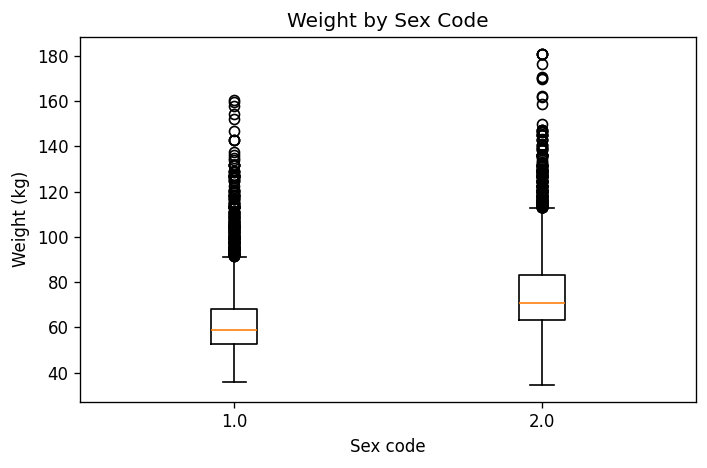

In [186]:
sex_weight = (
    cont_valid.groupby("WhatIsYourSex")[CONT_VAR]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)
sex_weight.to_csv(TAB_DIR / "02_weight_by_sex_code.csv", index=False)
display(sex_weight)

groups = [grp[CONT_VAR].values for _, grp in cont_valid.groupby("WhatIsYourSex")]
labels = [str(code) for code, _ in cont_valid.groupby("WhatIsYourSex")]

plt.figure(figsize=(6, 4))
plt.boxplot(groups, tick_labels=labels)
plt.title("Weight by Sex Code")
plt.xlabel("Sex code")
plt.ylabel("Weight (kg)")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_weight_by_sex_code_boxplot.png", bbox_inches="tight")
plt.show()

**Interpretation:** The boxplot and summary table show a clear difference in weight by sex code. Sex code 2 has a higher mean and median weight than sex code 1, indicating that this group tends to be heavier overall. Both groups show wide variability and many upper outliers, but the overall distribution for sex code 2 is consistently higher.